In [59]:
import warnings
warnings.filterwarnings("ignore")
from test_multicommodity import test_main, create_forcing, plot_result
from mcopt_misc import plot_network, run_mcopt
import sys
sys.path.append('../src/')
import numpy as np
from mcopt import McOpt, paris_topology
from typing import Dict, List, Tuple
import networkx as nx

#### Compare With McOpt

In [8]:
def constrcut_mcopt(beta: float=1.0, method="paris"):
    method, coupling, museed, pflux, rho = method, "l1", 0, beta, 0.0   
    time_step, tot_time, relax_linsys, tau_cond_dyn, tau_cost_dyn = 0.5, 10000, 1.0e-5, 1.0e-1, 1.0e-1
    tau_cond_opt, tau_cost_opt = 1.0e-1, 1.0e-1
    VERBOSE = False
    mcopt = McOpt(method, coupling, museed, pflux, VERBOSE, rho, relax_linsys, tau_cond_dyn, tau_cost_dyn, time_step, tot_time, tau_cond_opt, tau_cost_opt)
    mcopt.ot_setup()
    return mcopt

In [19]:
def compare_mcopt_admk(beta: float=1.0, method="paris"):
    mcopt = constrcut_mcopt(beta=beta, method=method)
    forcing, conductivity_mcopt = run_mcopt(mcopt)
    topo, weights, forcing_ = mcopt.export_setup()
    potentials, conductivity_admk = test_main(topo.copy(), weights, len(forcing_), forcing_, beta=beta, max_iter=25)
    plot_network(mcopt.g, forcing, conductivity_mcopt, conductivity_admk)
    return mcopt.g, forcing_

* graph topology construction
* running [dynamics]
	convergence achieved [dynamics]
* export fluxes
* export cost
init signature: (self, tol_optimization=0.001, tol_constraint=1e-08, method='explicit_tdens', max_iter=200, max_restart=5, method_ctrl=None, verbose=0, log=0, log_file='admk.log', beta=1, log_print: bool = True)
ierr=0 avg_it=0010 max(res)=7.4e-09 max(pres)=6.4e-12
   -2.00e+00<=UPDATE<=-2.00e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=1 var=1.11e+00
   -1.80e+00<=UPDATE<=-1.80e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=2 var=1.11e+00
   -1.62e+00<=UPDATE<=-1.62e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=3 var=1.11e+00
   -1.46e+00<=UPDATE<=-1.46e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=4 var=1.11e+00
   -1.31e+00<=UPDATE<=-1.31e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=5 var=1.11e+00
   -1.18e+00<=U

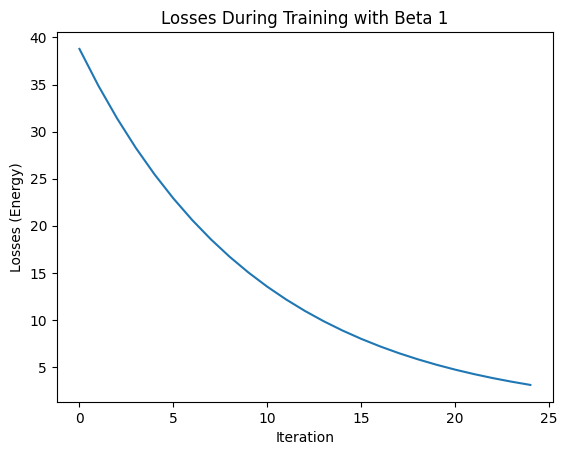

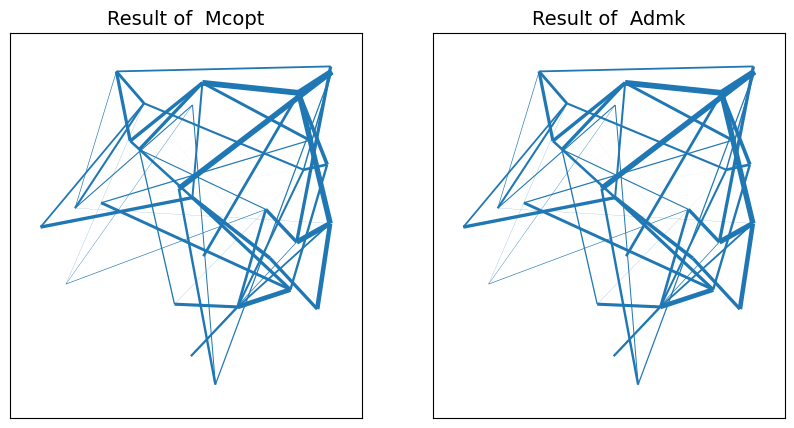

In [37]:
graph, forcing = compare_mcopt_admk(1, "synth")

###### Apply Fine-Grain Method On Waxman Graph

In [69]:
mesh_size = 50
num_commodity = len(graph.nodes)
def grid_coord_idx(coord: Tuple[int, int]): 
    return coord[0] * mesh_size + coord[1]
    
mesh = nx.grid_2d_graph(mesh_size, mesh_size)
forcing_grid = [np.zeros(num_commodity)] * (mesh_size * mesh_size)
for node in graph.nodes:
    cur_pos_on_grid: Tuple[int, int] = (round(graph.nodes[node]["pos"][0] * mesh_size), round(graph.nodes[node]["pos"][1] * mesh_size))
    cur_pos_idx = grid_coord_idx(cur_pos_on_grid)
    for comm in range(num_commodity):
        forcing_grid[cur_pos_idx][comm] += forcing[node][comm]
print(forcing_grid)

[array([-5.75901003e-06, -1.56234950e-07, -4.33022877e-06, -5.84869299e-06,
       -7.66420840e-06, -2.92122838e-06, -7.54861111e-06,  9.73207777e-06,
        1.49496824e-05, -7.86360364e-06,  3.62393414e-06, -6.19343819e-06,
       -5.29204334e-06,  1.20999161e-05, -2.76370367e-06, -3.30865647e-06,
       -8.45854735e-07,  5.95977081e-06,  2.89774841e-06,  8.28997752e-06,
        1.61231808e-05,  4.03207353e-06, -7.29439988e-06,  3.02297361e-06,
       -4.27755551e-06, -3.13057413e-06, -4.97521786e-06,  1.35031762e-05,
       -6.33516216e-06, -7.72608705e-06]), array([-5.75901003e-06, -1.56234950e-07, -4.33022877e-06, -5.84869299e-06,
       -7.66420840e-06, -2.92122838e-06, -7.54861111e-06,  9.73207777e-06,
        1.49496824e-05, -7.86360364e-06,  3.62393414e-06, -6.19343819e-06,
       -5.29204334e-06,  1.20999161e-05, -2.76370367e-06, -3.30865647e-06,
       -8.45854735e-07,  5.95977081e-06,  2.89774841e-06,  8.28997752e-06,
        1.61231808e-05,  4.03207353e-06, -7.29439988e-06

In [55]:
def discretize(graph: nx.Graph, forcing: List[np.ndarray], mesh_size=50, beta=1, max_iter=10):
    num_commodity = len(graph.nodes)
    def grid_coord_idx(coord: Tuple[int, int]): 
        return coord[0] * mesh_size + coord[1]
    
    mesh = nx.grid_2d_graph(mesh_size, mesh_size)
    forcing_grid = [np.zeros(num_commodity)] * (mesh_size * mesh_size)
    for node in graph.nodes:
        cur_pos_on_grid: Tuple[int, int] = (round(graph.nodes[node]["pos"][0] * mesh_size), round(graph.nodes[node]["pos"][1] * mesh_size))
        cur_pos_idx = grid_coord_idx(cur_pos_on_grid)
        for comm in range(num_commodity):
            forcing_grid[cur_pos_idx][comm] = forcing[node][comm]
    edge_lists = np.array([list((idx(e[0]), idx(e[1]))) for e in mesh.edges()])
    weights = np.ones_like(edge_lists[:,0])
    potentials, conductivity_admk = test_main(edge_lists, weights, len(forcing_grid), forcing_grid, beta=beta, max_iter=max_iter)
            

SyntaxError: invalid syntax (162083213.py, line 12)